Diabetes results
Accuracy : 0.7857
Precision: 0.7027
Recall   : 0.5417
F1       : 0.6118


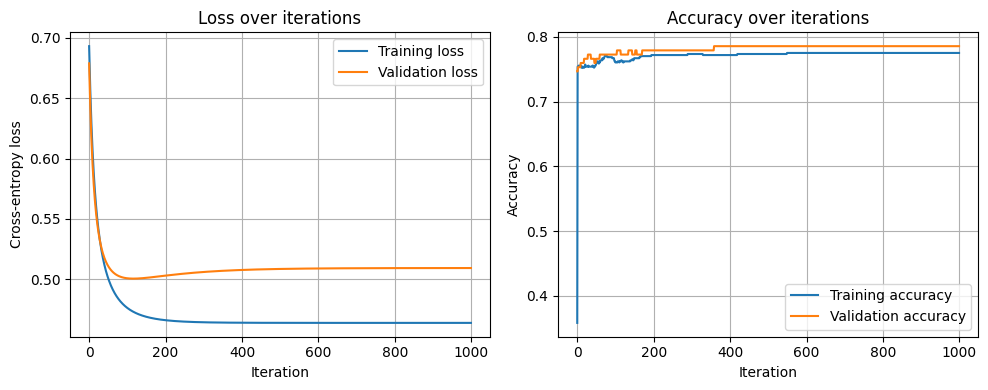

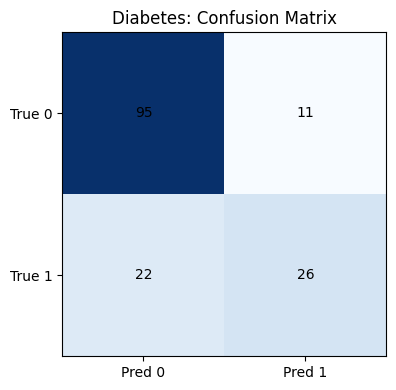

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

data = pd.read_csv("/content/diabetes.csv")

feature_cols = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
                "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]

X = data[feature_cols].values
y = data["Outcome"].values
m = len(y)

np.random.seed(7)
indices = np.random.permutation(m)

split_index = int(0.8 * m)

training_indices = indices[:split_index]
validation_indices   = indices[split_index:]

X_train = X[training_indices]
y_train = y[training_indices]

X_val   = X[validation_indices]
y_val   = y[validation_indices]

mean = X_train.mean(axis=0)
std  = X_train.std(axis=0)

X_train = (X_train - mean) / std
X_val   = (X_val   - mean) / std

X_train = np.hstack([np.ones((len(y_train), 1)), X_train])
X_val   = np.hstack([np.ones((len(y_val),   1)), X_val])

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def train_logistic(X_train, y_train, X_val, y_val,
                   alpha=0.1, iterations=1000, lambda_value=0.0):

#lambda_value = L2 weight penalty (0 = no regularization)

    n = X_train.shape[1]
    theta = np.zeros(n)

    m_train = len(y_train)
    m_val   = len(y_val)

    train_loss_history, val_loss_history = [], []
    train_acc_history,  val_acc_history  = [], []

    eps = 1e-9

    for i in range(iterations):
        #training data
        z = X_train @ theta #shape
        p = sigmoid(z) #probability predictions

        #cross-entropy loss gradient
        error = p - y_train
        grad = (1.0 / m_train) * (X_train.T @ error)

        #L2 penalty gradient
        if lambda_value > 0:
            reg = (lambda_value / m_train) * theta.copy()
            reg[0] = 0.0 # no bias penalty
            grad = grad + reg

        theta = theta - alpha * grad

        #training loss
        train_loss = -np.mean(
            y_train * np.log(p + eps) + (1 - y_train) * np.log(1 - p + eps)
        )
        if lambda_value > 0:
            train_loss += (lambda_value / (2.0 * m_train)) * np.sum(theta[1:] ** 2)
        train_loss_history.append(train_loss)

        #training accuracy
        train_preds = (p >= 0.5).astype(int)
        train_acc_history.append(np.mean(train_preds == y_train))

        #validation loss / accuracy
        p_val = sigmoid(X_val @ theta)
        val_loss = -np.mean(
            y_val * np.log(p_val + eps) + (1 - y_val) * np.log(1 - p_val + eps)
        )
        if lambda_value > 0:
            val_loss += (lambda_value / (2.0 * m_val)) * np.sum(theta[1:] ** 2)
        val_loss_history.append(val_loss)

        val_preds = (p_val >= 0.5).astype(int)
        val_acc_history.append(np.mean(val_preds == y_val))

    return theta, train_loss_history, val_loss_history, train_acc_history, val_acc_history

def evaluate(theta, X, y):
    p = sigmoid(X @ theta)
    preds = (p >= 0.5).astype(int)

    TP = np.sum((preds == 1) & (y == 1))
    TN = np.sum((preds == 0) & (y == 0))
    FP = np.sum((preds == 1) & (y == 0))
    FN = np.sum((preds == 0) & (y == 1))

    accuracy  = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0

    #rows = true / columns = predicted
    cm = np.array([[TN, FP],
                   [FN, TP]])
    return accuracy, precision, recall, f1, cm


def plot_confusion_matrix(cm, title):
    fig, ax = plt.subplots(figsize=(4.5, 4))
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred 0", "Pred 1"])
    ax.set_yticklabels(["True 0", "True 1"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", color="black")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

theta, tr_loss, val_loss, tr_acc, val_acc = train_logistic(
    X_train, y_train, X_val, y_val, alpha=0.1, iterations=1000, lambda_value=0.0
)

acc, prec, rec, f1, cm = evaluate(theta, X_val, y_val)
print("Diabetes results")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1       : {f1:.4f}")

#loss curves
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(tr_loss,  label="Training loss")
plt.plot(val_loss, label="Validation loss")
plt.xlabel("Iteration")
plt.ylabel("Cross-entropy loss")
plt.title("Loss over iterations")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(tr_acc,  label="Training accuracy")
plt.plot(val_acc, label="Validation accuracy")
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.title("Accuracy over iterations")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plot_confusion_matrix(cm, "Diabetes: Confusion Matrix")

Cancer (no penalty)
Accuracy 0.9825 | Prec 0.9778 | Rec 0.9778 | F1 0.9778


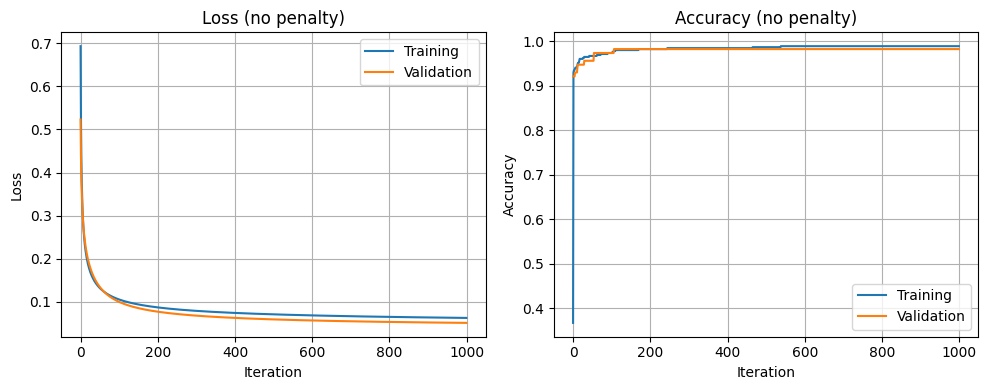

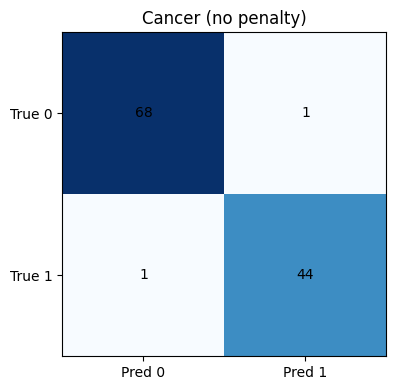

Cancer (L2 penalty, lambda_value=1.0)
Acc 0.9825 | Precision 0.9778 | Recall 0.9778 | F1 0.9778


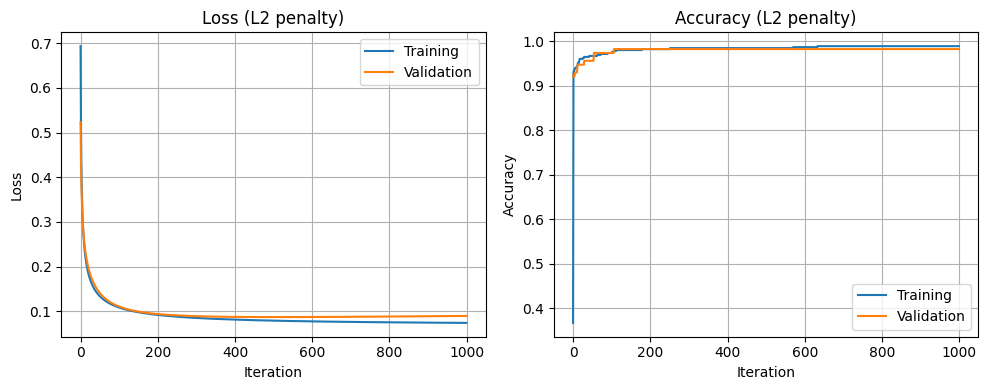

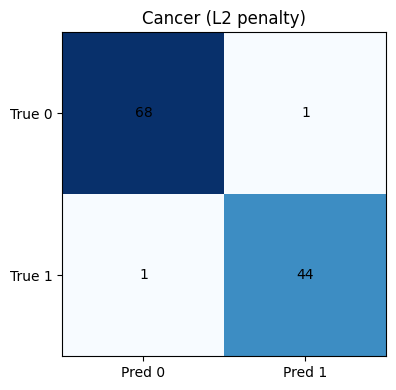

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

data = pd.read_csv("/content/Cancer.csv")

y = (data["diagnosis"] == "M").astype(int).values #malignant = 1 / benign = 0
X = data.drop(columns=["id", "diagnosis", "Unnamed: 32"], errors="ignore").values
m = len(y)

np.random.seed(7)
indices = np.random.permutation(m)
split_index = int(0.8 * m)

training_indices = indices[:split_index]
validation_indices   = indices[split_index:]

X_train = X[training_indices]
Y_train = y[training_indices]
X_val   = X[validation_indices]
Y_val   = y[validation_indices]

#standardize
mean = X_train.mean(axis=0)
std  = X_train.std(axis=0)
X_train = (X_train - mean) / std
X_val   = (X_val   - mean) / std

X_train = np.hstack([np.ones((len(Y_train), 1)), X_train])
X_val   = np.hstack([np.ones((len(Y_val),   1)), X_val])

#no weight penalty
theta, train_loss, val_loss, train_acc, val_acc = train_logistic(
    X_train, Y_train, X_val, Y_val, alpha=0.1, iterations=1000, lambda_value=0.0
)
acc, prec, rec, f1, cm = evaluate(theta, X_val, Y_val)
print("Cancer (no penalty)")
print(f"Accuracy {acc:.4f} | Prec {prec:.4f} | Rec {rec:.4f} | F1 {f1:.4f}")

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(train_loss, label="Training")
plt.plot(val_loss, label="Validation")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Loss (no penalty)")
plt.legend()
plt.grid(True)
plt.subplot(1,2,2)
plt.plot(train_acc, label="Training")
plt.plot(val_acc, label="Validation")
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.title("Accuracy (no penalty)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
plot_confusion_matrix(cm, "Cancer (no penalty)")


#L2 weight penalty
theta2, train_loss2, val_loss2, train_acc2, val_acc2 = train_logistic(
    X_train, Y_train, X_val, Y_val, alpha=0.1, iterations=1000, lambda_value=1.0
)
acc2, prec2, rec2, f12, cm2 = evaluate(theta2, X_val, Y_val)
print("Cancer (L2 penalty, lambda_value=1.0)")
print(f"Acc {acc2:.4f} | Precision {prec2:.4f} | Recall {rec2:.4f} | F1 {f12:.4f}")

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(train_loss2, label="Training")
plt.plot(val_loss2, label="Validation")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Loss (L2 penalty)")
plt.legend()
plt.grid(True)
plt.subplot(1,2,2)
plt.plot(train_acc2, label="Training")
plt.plot(val_acc2, label="Validation")
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.title("Accuracy (L2 penalty)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
plot_confusion_matrix(cm2, "Cancer (L2 penalty)")